# GNN Explainability with GNNExplainer

Deep GNNs can often feel like a black box. In this notebook, we use PyTorch Geometric's modern `Explainer` API with the **GNNExplainer** algorithm to explain GCN predictions on the **Cora** dataset.

**We select and interpret two nodes representing polar structural cases:**
1. **Highly Normal Node**: A node with a low Isolation Forest anomaly score that lives deep in a dense class cluster.
2. **Highly Anomalous Node**: A node with a very high Isolation Forest anomaly score (typically on a class boundary or structurally isolated).

For each node, GNNExplainer optimizes masks to find the **most important subset of edges (graph structure)** and **most important features (node attributes)** driving the model's classification prediction.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.ensemble import IsolationForest

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import k_hop_subgraph, to_networkx

from main import load_dataset, build_model, set_seed
from train import train_one_epoch
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


## Train GCN and locate Normal vs. Anomalous Nodes

In [2]:
set_seed(42)
data_params = DataParams(dataset_name='cora', seed=42)
ds_info = load_dataset(data_params)
data = ds_info['data'].to(DEVICE)
train_mask = ds_info['train_mask'].to(DEVICE)
val_mask = ds_info['val_mask'].to(DEVICE)

model_params = ModelParams(model_name='gcn', hidden_channels=64, num_layers=2, dropout=0.5)
model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], 'node').to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for _ in range(80):
    train_one_epoch(model, 'node', optimizer, DEVICE, data=data, train_mask=train_mask)

# Extract embeddings & anomalies
emb = model.embed(data.x, data.edge_index).cpu().numpy()
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(emb)
anomaly_scores = -iso.score_samples(emb)

# Identify target nodes to explain
normal_node = int(np.argmin(anomaly_scores))
anomalous_node = int(np.argmax(anomaly_scores))

print(f'Normal Node Selected: {normal_node} (Score={anomaly_scores[normal_node]:.3f})')
print(f'Anomalous Node Selected: {anomalous_node} (Score={anomaly_scores[anomalous_node]:.3f})')

Normal Node Selected: 1323 (Score=0.378)
Anomalous Node Selected: 306 (Score=0.679)


## Set up GNNExplainer

In [3]:
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=100),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='log_probs',
    ),
)
print('Explainer setup initialized.')

Explainer setup initialized.


## Generate Explanations

In [4]:
print(f'Explaining normal node {normal_node}...')
explanation_normal = explainer(data.x, data.edge_index, index=normal_node)

print(f'Explaining anomalous node {anomalous_node}...')
explanation_anomalous = explainer(data.x, data.edge_index, index=anomalous_node)

print('Explanations complete!')

Explaining normal node 1323...


Explaining anomalous node 306...


Explanations complete!


## Visualizing the Explained Subgraphs

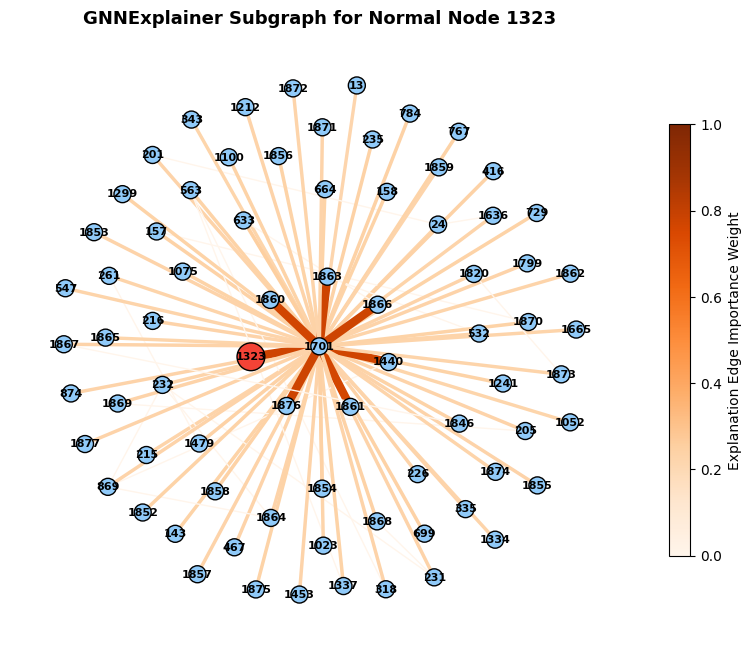

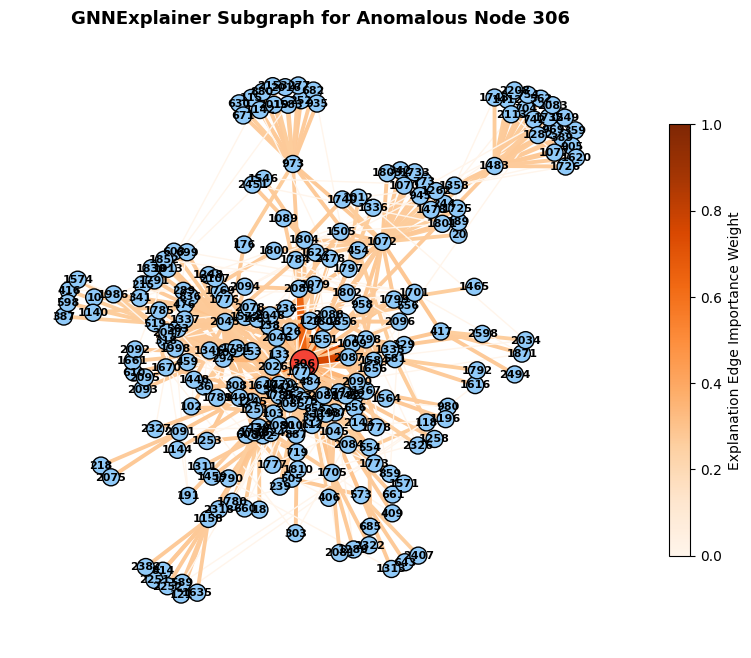

In [5]:
def draw_explanation_subgraph(explanation, target_node, title, filename):
    """Draw the local 2-hop neighborhood of a node with edges sized/colored by importance."""
    # Get local k-hop neighborhood from pyG
    node_idx, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        target_node, num_hops=2, edge_index=explanation.edge_index, relabel_nodes=True
    )
    
    # Map edge_mask weights from explanation
    sub_weights = explanation.edge_mask[edge_mask].cpu().numpy()
    
    # Build networkx graph
    # Build edge list with weights
    edge_list = []
    for idx in range(sub_edge_index.size(1)):
        u = int(sub_edge_index[0, idx])
        v = int(sub_edge_index[1, idx])
        w = float(sub_weights[idx])
        edge_list.append((u, v, w))
        
    G = nx.Graph()
    G.add_nodes_from(range(len(node_idx)))
    for u, v, w in edge_list:
        # Undirected graph aggregation
        if G.has_edge(u, v):
            G[u][v]['weight'] = max(G[u][v]['weight'], w)
        else:
            G.add_edge(u, v, weight=w)
            
    # Position
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    
    # Colors: target node is highlighted in Red, neighbors are Light Blue
    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if n == int(mapping):
            node_colors.append('#F44336') # target red
            node_sizes.append(400)
        else:
            node_colors.append('#90CAF9') # light blue
            node_sizes.append(150)
            
    # Edges: width and color mapped to weight importance
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    # Normalize widths to range [1, 6]
    max_w = max(weights) if len(weights) > 0 else 1e-12
    edge_widths = [1 + 5 * (w / max_w) for w in weights]
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_labels(G, pos, labels={n: int(node_idx[n]) for n in G.nodes()}, font_size=8, font_weight='bold')
    
    # Edge drawing with colormap
    edge_collection = nx.draw_networkx_edges(
        G, pos, edgelist=edges, width=edge_widths, edge_color=weights,
        edge_cmap=plt.cm.Oranges, edge_vmin=0, edge_vmax=1
    )
    
    # Add colorbar for edge importance
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Oranges, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=plt.gca(), shrink=0.7, label='Explanation Edge Importance Weight')
    
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()

# Draw normal node explanation
draw_explanation_subgraph(explanation_normal, normal_node, 
                          f'GNNExplainer Subgraph for Normal Node {normal_node}', 
                          'explain_normal_node.png')

# Draw anomalous node explanation
draw_explanation_subgraph(explanation_anomalous, anomalous_node, 
                          f'GNNExplainer Subgraph for Anomalous Node {anomalous_node}', 
                          'explain_anomalous_node.png')

## Feature Mask Importance Analysis

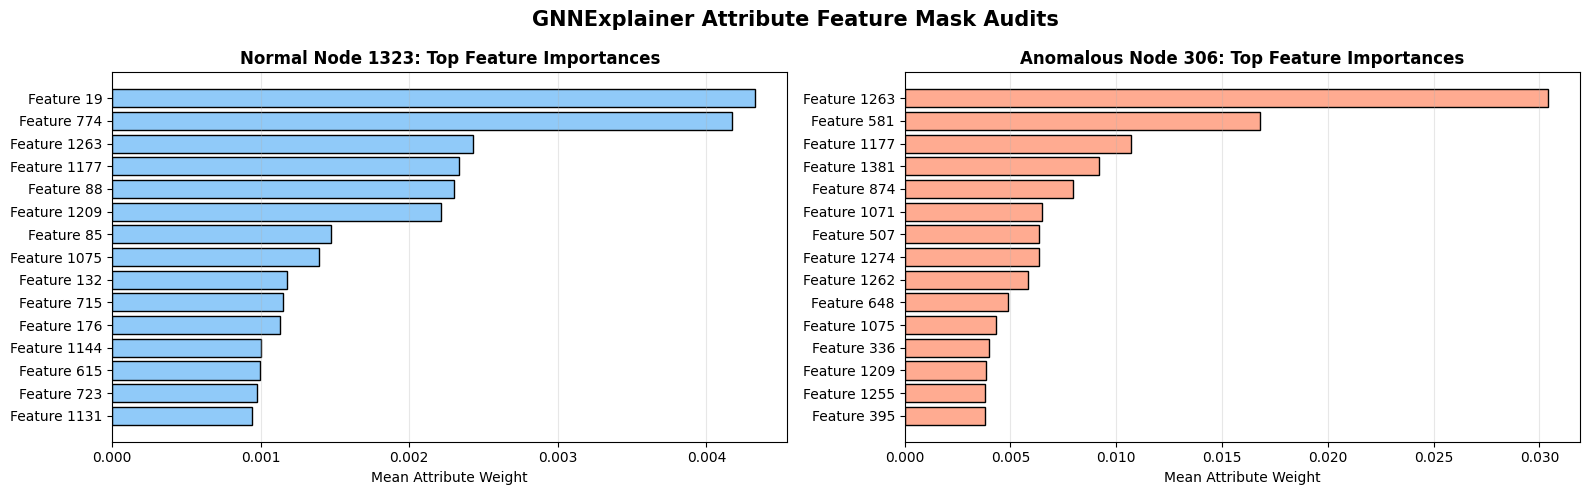

In [6]:
# Plot the feature importances (top 15 features)
feat_importance_norm = explanation_normal.node_mask.mean(dim=0).cpu().numpy()
feat_importance_anom = explanation_anomalous.node_mask.mean(dim=0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_k = 15
# Normal Node Feature Importances
ax = axes[0]
top_norm_idx = np.argsort(feat_importance_norm)[-top_k:]
ax.barh(range(top_k), feat_importance_norm[top_norm_idx], color='#90CAF9', edgecolor='black')
ax.set_yticks(range(top_k))
ax.set_yticklabels([f'Feature {idx}' for idx in top_norm_idx])
ax.set_title(f'Normal Node {normal_node}: Top Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Attribute Weight')
ax.grid(True, axis='x', alpha=0.3)

# Anomalous Node Feature Importances
ax = axes[1]
top_anom_idx = np.argsort(feat_importance_anom)[-top_k:]
ax.barh(range(top_k), feat_importance_anom[top_anom_idx], color='#FFAB91', edgecolor='black')
ax.set_yticks(range(top_k))
ax.set_yticklabels([f'Feature {idx}' for idx in top_anom_idx])
ax.set_title(f'Anomalous Node {anomalous_node}: Top Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Attribute Weight')
ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('GNNExplainer Attribute Feature Mask Audits', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('explain_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()